# Дерево решений — регрессор

## Задача
В данной работе рассматривается применение дерева решений для задачи регрессии.  
Необходимо обучить модель `DecisionTreeRegressor` на реальных данных, получить предсказания, оценить качество модели с помощью метрик и проанализировать результат с помощью графиков.

## Датасет
В работе используется датасет **Diabetes** из библиотеки `sklearn`.  
Он содержит медицинские данные пациентов и применяется для задачи регрессии, то есть для предсказания числового значения.

В датасете:

- **442 объекта** — это пациенты,
- **10 признаков** — характеристики пациентов,
- **целевая переменная** — числовой показатель, количественная мера прогрессирования заболевания через год.

| Признак | Краткое описание |
|---|---|
| age | возраст |
| sex | пол |
| bmi | индекс массы тела |
| bp | артериальное давление |
| s1 | показатель, связанный с сывороткой крови |
| s2 | сывороточный показатель |
| s3 | биохимический показатель |
| s4 | биохимический показатель |
| s5 | биохимический показатель |
| s6 | биохимический показатель |

## Целевая переменная
Целевая переменная `target` — это числовое значение, которое отражает степень прогрессирования заболевания.  

## Используемые библиотеки

В работе используются `numpy`, `pandas`, `matplotlib` и компоненты `sklearn` для обучения дерева решений-регрессора и оценки качества прогноза


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target

feature_names = diabetes.feature_names

print("Размер X:", X.shape)
print("Размер y:", y.shape)
print("\nПризнаки:")
print(feature_names)

Размер X: (442, 10)
Размер y: (442,)

Признаки:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


## Предварительная обработка датасета

Создаём табличное представление датасета и проверяем данные перед обучением


In [4]:
df_diabetes = pd.DataFrame(X, columns=feature_names)

print('Первые 5 строк датасета:')
display(df_diabetes.head())
print(f'Пропусков в признаках: {int(df_diabetes.isna().sum().sum())}')
print(f'Дубликатов строк:      {int(df_diabetes.duplicated().sum())}')


Первые 5 строк датасета:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


Пропусков в признаках: 0
Дубликатов строк:      0


## Тепловая карта

Строим тепловую карту корреляций между признаками `Diabetes`


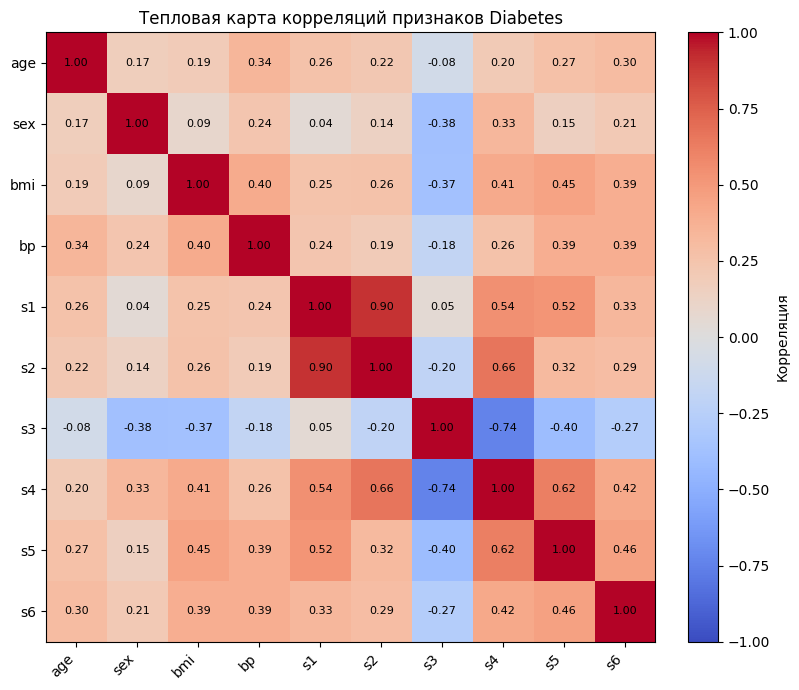

In [5]:
heatmap_features = list(feature_names)
if len(heatmap_features) > 12:
    heatmap_features = heatmap_features[:12]

corr_matrix = df_diabetes[heatmap_features].corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(heatmap_features)))
ax.set_yticks(range(len(heatmap_features)))
ax.set_xticklabels(heatmap_features, rotation=45, ha='right')
ax.set_yticklabels(heatmap_features)
ax.set_title('Тепловая карта корреляций признаков Diabetes')

for i in range(len(heatmap_features)):
    for j in range(len(heatmap_features)):
        ax.text(j, i, f"{corr_matrix.values[i, j]:.2f}", ha='center', va='center', color='black', fontsize=8)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Корреляция')
plt.tight_layout()
plt.show()


# Обучение

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=42
)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

Размер обучающей выборки: (397, 10)
Размер тестовой выборки: (45, 10)


In [7]:
reg_tree = DecisionTreeRegressor(
    max_depth=4,
    random_state=42
)

reg_tree.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

## Прогнозы модели

Сравниваем реальные значения и прогнозы дерева решений для задачи регрессии


In [8]:
y_pred = reg_tree.predict(X_test)

print("Первые 10 реальных значений:")
print(y_test[:10])

print("\nПервые 10 предсказанных значений:")
print(y_pred[:10])

Первые 10 реальных значений:
[219.  70. 202. 230. 111.  84. 242. 272.  94.  96.]

Первые 10 предсказанных значений:
[177.45833333 187.66666667 177.45833333 236.55172414 105.98734177
  89.35714286 243.75       236.55172414 134.20689655 137.34782609]


# Оценка качества модели

In [9]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Метрики качества модели:")
print("MAE  =", mae)
print("MSE  =", mse)
print("RMSE =", rmse)
print("R2   =", r2)

Метрики качества модели:
MAE  = 39.32350291541661
MSE  = 2758.0311747702103
RMSE = 52.51696082952831
R2   = 0.549111737767743


## Графики выходных результатов

Визуализируем качество прогноза и вклад признаков в регрессионное дерево


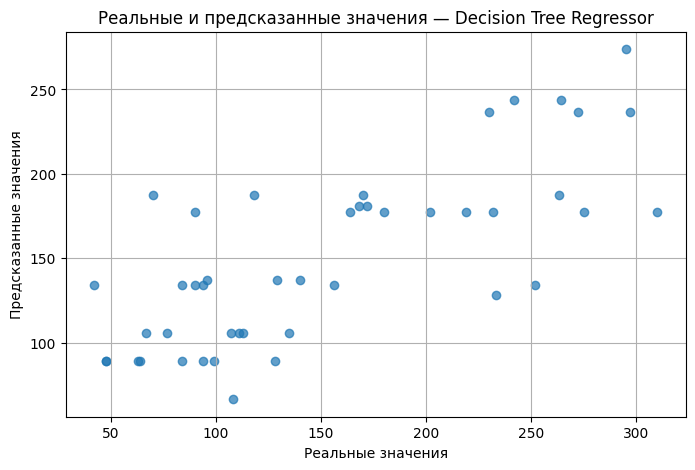

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Реальные значения")
plt.ylabel("Предсказанные значения")
plt.title("Реальные и предсказанные значения — Decision Tree Regressor")
plt.grid(True)
plt.show()

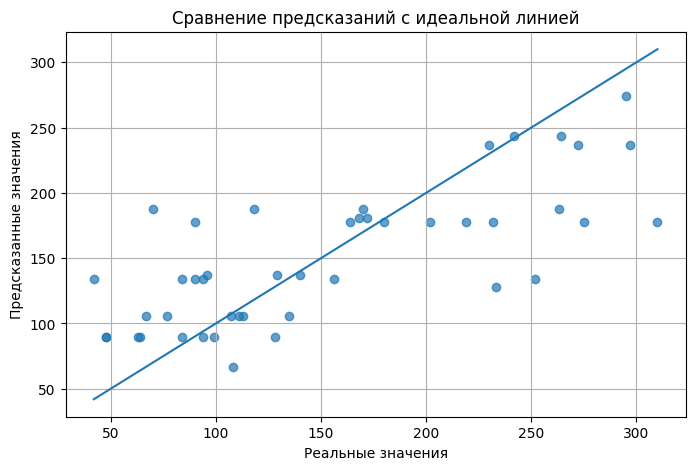

In [11]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.7)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val])
plt.xlabel("Реальные значения")
plt.ylabel("Предсказанные значения")
plt.title("Сравнение предсказаний с идеальной линией")
plt.grid(True)
plt.show()

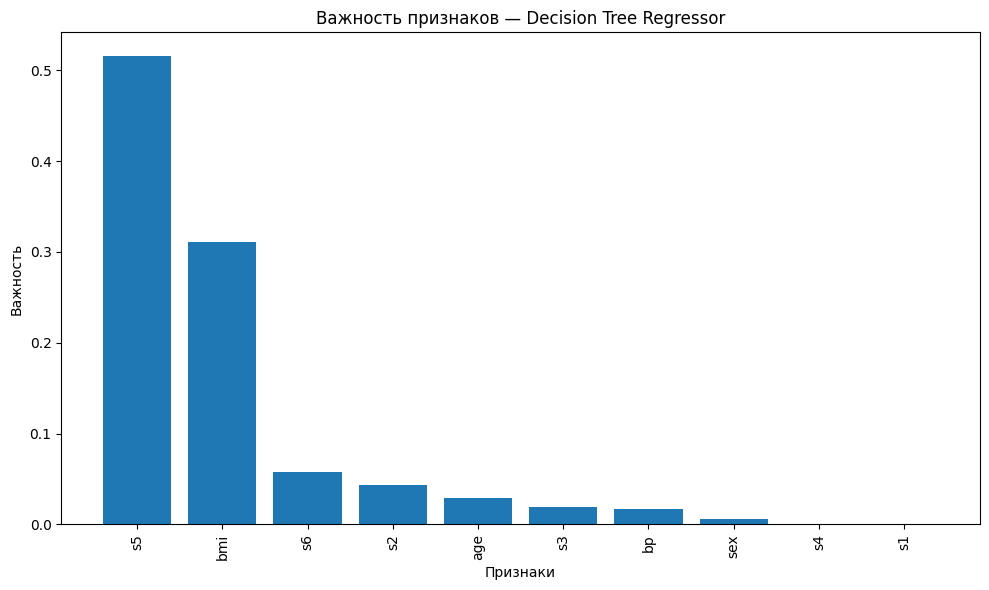

In [12]:
importances = reg_tree.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), np.array(feature_names)[indices], rotation=90)
plt.xlabel("Признаки")
plt.ylabel("Важность")
plt.title("Важность признаков — Decision Tree Regressor")
plt.tight_layout()
plt.show()